# 6 · Binary CNN Classifier — Baseline 2 (Supervised Upper Bound)

### Supervised vs. One-Class Anomaly Detection

Unlike Deep SVDD and the Autoencoder, this model is **supervised**. It is trained with labelled examples of both normal and anomaly patches using binary cross-entropy loss.

**This is not a true anomaly detection model** — it breaks the one-class constraint.  
Its purpose is to provide a **performance ceiling**: the best achievable result if we had labelled damage data during training.

Comparing our unsupervised primary model against this supervised upper bound shows how much performance we sacrifice for not using damage labels.

**Class imbalance handling:**  
Since ~88–92% of patches are normal, we compute **class weights** inversely proportional to class frequency and pass them to `BCEWithLogitsLoss`. This prevents the model from simply predicting normal for every patch.

**Transfer learning:**  
ResNet-18 pre-trained on ImageNet, with partial freezing tuned via hyperparameter search.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import importlib
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import src.dataset as _ds_mod; importlib.reload(_ds_mod)
from src.dataset     import CrackDataset, load_splits
from src.models      import ResNet18Classifier
from src.train_utils import (train_classifier_epoch, eval_classifier_epoch,
                              eval_scores, calibrate_threshold,
                              compute_metrics, print_metrics,
                              save_checkpoint, load_checkpoint)
from src.viz_utils   import (plot_loss_curves, plot_roc_curve, plot_pr_curve,
                              plot_confusion_matrix, plot_score_histogram,
                              plot_patches_grid)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

SPLITS_DIR      = 'splits'
CHECKPOINTS_DIR = 'checkpoints'
RESULTS_DIR     = 'results'
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


Device : cuda


In [3]:
train_records, val_records, test_records = load_splits(SPLITS_DIR)

PREPROCESSING = 'none'   # 'lime' | 'clahe' | 'none'
BATCH_SIZE    = 64

# Binary CNN uses ALL patches (normal + anomaly) for supervised training
train_ds = CrackDataset(train_records, preprocessing=PREPROCESSING, augment=True)
val_ds   = CrackDataset(val_records,   preprocessing=PREPROCESSING, augment=False)
test_ds  = CrackDataset(test_records,  preprocessing=PREPROCESSING, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

# Compute class weights for imbalanced BCE loss
train_labels = np.array([r['label'] for r in train_records])
n_normal     = (train_labels == 0).sum()
n_anomaly    = (train_labels == 1).sum()
pos_weight   = torch.tensor([n_normal / n_anomaly], dtype=torch.float32).to(device)

print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}  Test: {len(test_ds):,}')
print(f'Normal: {n_normal:,}  Anomaly: {n_anomaly:,}  pos_weight: {pos_weight.item():.2f}')


Train: 17,033  Val: 3,650  Test: 3,651
Normal: 15,207  Anomaly: 1,826  pos_weight: 8.33


### 3. Model Architecture

ResNet-18 with ImageNet pre-training. The final fully-connected layer is replaced with a single output neuron + sigmoid for binary classification.  
Early layers are frozen and the freeze depth is selected by the hyperparameter search below.

In [4]:
model = ResNet18Classifier(freeze_up_to='layer2', pretrained=True).to(device)
print(model.model)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'\nTrainable: {trainable:,} / Total: {total:,}  ({trainable/total*100:.1f}%)')

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 4. Mini Hyperparameter Search

We search over learning rate, weight decay, LR scheduler, and freezing strategy.  
Each config runs for 5 epochs and is evaluated on val AUROC.

In [5]:
from sklearn.metrics import roc_auc_score

HP_GRID = [
    {'lr': 1e-3,  'wd': 0,    'freeze': 'layer2', 'scheduler': 'cosine'},
    {'lr': 1e-4,  'wd': 0,    'freeze': 'layer2', 'scheduler': 'cosine'},
    {'lr': 5e-5,  'wd': 0,    'freeze': 'layer2', 'scheduler': 'cosine'},
    {'lr': 1e-4,  'wd': 1e-4, 'freeze': 'layer2', 'scheduler': 'cosine'},
    {'lr': 1e-4,  'wd': 0,    'freeze': 'layer1', 'scheduler': 'cosine'},
    {'lr': 1e-4,  'wd': 0,    'freeze': 'layer3', 'scheduler': 'cosine'},
    {'lr': 1e-4,  'wd': 0,    'freeze': None,     'scheduler': 'cosine'},
    {'lr': 1e-4,  'wd': 0,    'freeze': 'layer2', 'scheduler': None},
]
QUICK_EPOCHS = 5

criterion_sweep = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
hp_results      = []

for i, hp in enumerate(HP_GRID):
    m   = ResNet18Classifier(freeze_up_to=hp['freeze'], pretrained=True).to(device)
    opt = optim.Adam(filter(lambda p: p.requires_grad, m.parameters()),
                     lr=hp['lr'], weight_decay=hp['wd'])
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=QUICK_EPOCHS) \
          if hp['scheduler'] == 'cosine' else None

    for _ in range(QUICK_EPOCHS):
        train_classifier_epoch(m, train_loader, opt, criterion_sweep, device, sch)

    val_scores, val_labels = eval_scores(m, val_loader, device)
    auroc = roc_auc_score(val_labels, val_scores)
    hp_results.append({**hp, 'val_auroc': auroc})
    print(f"Config {i+1:2d}: lr={hp['lr']:.0e}  wd={hp['wd']:.0e}  "
          f"freeze={str(hp['freeze']):8s}  sched={str(hp['scheduler']):6s}  "
          f"→ val_AUROC={auroc:.4f}")

best_hp = max(hp_results, key=lambda r: r['val_auroc'])
print(f"\nBest config: {best_hp}")

Config  1: lr=1e-03  wd=0e+00  freeze=layer2    sched=cosine  → val_AUROC=0.9550
Config  2: lr=1e-04  wd=0e+00  freeze=layer2    sched=cosine  → val_AUROC=0.9611
Config  3: lr=5e-05  wd=0e+00  freeze=layer2    sched=cosine  → val_AUROC=0.9566
Config  4: lr=1e-04  wd=1e-04  freeze=layer2    sched=cosine  → val_AUROC=0.9587
Config  5: lr=1e-04  wd=0e+00  freeze=layer1    sched=cosine  → val_AUROC=0.9632
Config  6: lr=1e-04  wd=0e+00  freeze=layer3    sched=cosine  → val_AUROC=0.9532
Config  7: lr=1e-04  wd=0e+00  freeze=None      sched=cosine  → val_AUROC=0.9640
Config  8: lr=1e-04  wd=0e+00  freeze=layer2    sched=None    → val_AUROC=0.9603

Best config: {'lr': 0.0001, 'wd': 0, 'freeze': None, 'scheduler': 'cosine', 'val_auroc': 0.9639573747772252}


### 5. Full Training with Best Hyperparameters

In [6]:
NUM_EPOCHS = 20

model = ResNet18Classifier(
    freeze_up_to = best_hp['freeze'],
    pretrained   = True,
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=best_hp['lr'], weight_decay=best_hp['wd'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS) \
            if best_hp['scheduler'] == 'cosine' else None

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

print(f'Training Binary CNN for {NUM_EPOCHS} epochs...')
print(f'{"Epoch":>6}  {"TrLoss":>9}  {"TrAcc":>7}  {"ValLoss":>9}  {"ValAcc":>7}')

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc   = train_classifier_epoch(model, train_loader, optimizer,
                                                criterion, device, scheduler)
    val_loss, val_acc = eval_classifier_epoch(model, val_loader, criterion, device)

    train_losses.append(tr_loss);  val_losses.append(val_loss)
    train_accs.append(tr_acc);     val_accs.append(val_acc)

    print(f'[{epoch+1:>3}/{NUM_EPOCHS}]  '
          f'{tr_loss:.5f}  {tr_acc*100:.2f}%  {val_loss:.5f}  {val_acc*100:.2f}%')

print('\nTraining complete.')
save_checkpoint(model, f'{CHECKPOINTS_DIR}/binary_cnn.pth',
                extra={'train_losses': train_losses, 'val_losses': val_losses,
                       'best_hp': best_hp})

Training Binary CNN for 20 epochs...
 Epoch     TrLoss    TrAcc    ValLoss   ValAcc
[  1/20]  0.71431  83.97%  0.54055  87.32%
[  2/20]  0.54924  90.18%  0.47629  92.96%
[  3/20]  0.49897  90.35%  0.51401  94.03%
[  4/20]  0.45980  91.49%  0.49319  89.48%
[  5/20]  0.42746  92.11%  0.44979  93.10%
[  6/20]  0.40647  92.29%  0.40379  94.82%
[  7/20]  0.37609  93.05%  0.38609  93.89%
[  8/20]  0.36311  92.98%  0.40089  92.99%
[  9/20]  0.32203  93.93%  0.46738  93.32%
[ 10/20]  0.30977  94.18%  0.44986  94.60%
[ 11/20]  0.28323  94.58%  0.46657  94.74%
[ 12/20]  0.27045  94.79%  0.40116  93.26%
[ 13/20]  0.24056  94.93%  0.42097  94.25%
[ 14/20]  0.24030  95.44%  0.39768  94.66%
[ 15/20]  0.19770  96.20%  0.39915  94.36%
[ 16/20]  0.19933  96.27%  0.45521  94.90%
[ 17/20]  0.17471  96.58%  0.44108  94.41%
[ 18/20]  0.17234  96.61%  0.49956  95.78%
[ 19/20]  0.16937  96.75%  0.47359  95.64%
[ 20/20]  0.15439  96.99%  0.47525  96.03%

Training complete.
  Saved checkpoint → checkpoints/bin

### 6. Loss & Accuracy Curves

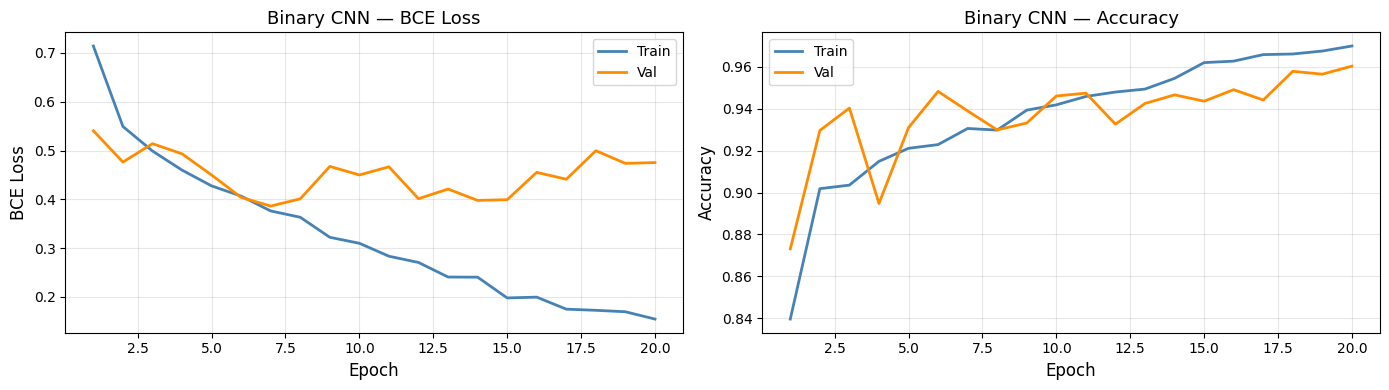

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_loss_curves(train_losses, val_losses,
                 title='Binary CNN — BCE Loss', ylabel='BCE Loss', ax=axes[0])
plot_loss_curves(train_accs, val_accs,
                 title='Binary CNN — Accuracy', ylabel='Accuracy', ax=axes[1])
plt.tight_layout()
plt.show()

### 7. Threshold Calibration & Test Evaluation

In [8]:
val_scores, val_labels   = eval_scores(model, val_loader,  device)
tau, val_f1              = calibrate_threshold(val_scores, val_labels)
print(f'Best threshold τ = {tau:.6f}  (val F1 = {val_f1:.4f})')

test_scores, test_labels = eval_scores(model, test_loader, device)
metrics = compute_metrics(test_scores, test_labels, tau)
print_metrics(metrics, model_name='Binary CNN')

results = {
    'scores': test_scores, 'labels': test_labels,
    'threshold': tau,
    **{k: v for k, v in metrics.items() if k != 'preds'},
    'train_losses': train_losses, 'val_losses': val_losses,
}
with open(f'{RESULTS_DIR}/results_binary_cnn.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Results saved.')

Best threshold τ = 0.723618  (val F1 = 0.8405)
[Binary CNN] AUROC: 0.9649  AUPRC: 0.8774  F1: 0.7973
  Confusion matrix:
    TN=  3200  FP=    60
    FN=    92  TP=   299
Results saved.


### 8. Performance Visualisations

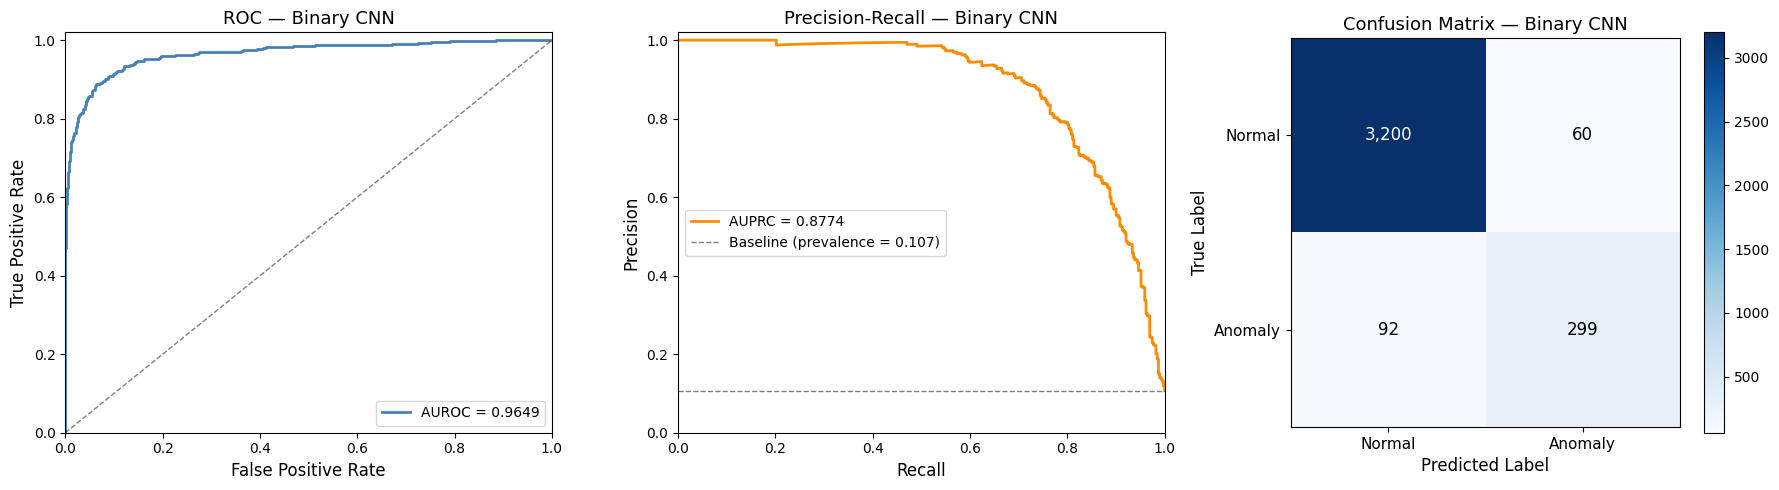

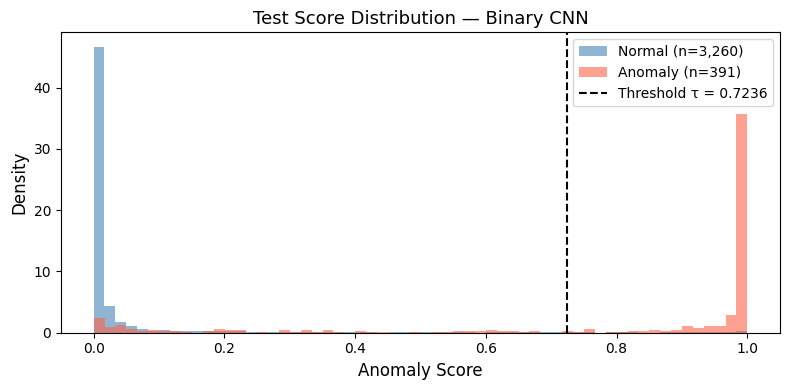

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_roc_curve(test_scores, test_labels, metrics['auroc'],
               title='ROC — Binary CNN', ax=axes[0])
plot_pr_curve(test_scores, test_labels, metrics['auprc'],
              title='Precision-Recall — Binary CNN', ax=axes[1])
plot_confusion_matrix(metrics['cm'], title='Confusion Matrix — Binary CNN', ax=axes[2])
plt.tight_layout()
plt.show()

ax = plot_score_histogram(test_scores, test_labels, threshold=tau,
                          title='Test Score Distribution — Binary CNN')
plt.tight_layout()
plt.show()

### 9. Failure Case Analysis

False Positives: 60  |  False Negatives: 92


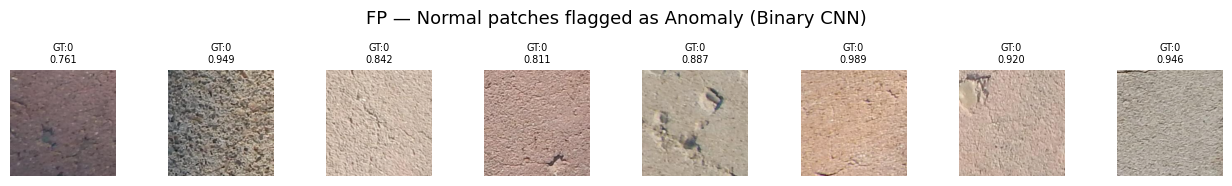

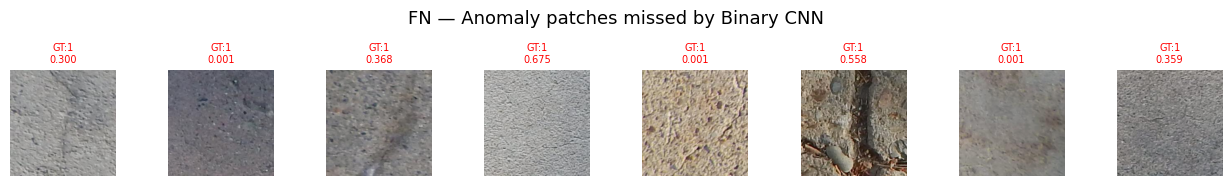

In [10]:
preds      = metrics['preds']
fp_indices = np.where((preds == 1) & (test_labels == 0))[0]
fn_indices = np.where((preds == 0) & (test_labels == 1))[0]
print(f'False Positives: {len(fp_indices):,}  |  False Negatives: {len(fn_indices):,}')

def get_patches_at_indices(dataset, indices, n=8):
    indices = indices[:n]
    xs, ys = [], []
    for i in indices:
        x, y = dataset[i]; xs.append(x); ys.append(y)
    return torch.stack(xs), torch.stack(ys)

if len(fp_indices) >= 8:
    fp_x, fp_y = get_patches_at_indices(test_ds, fp_indices[:8])
    plot_patches_grid(fp_x, fp_y, scores=test_scores[fp_indices[:8]],
                      title='FP — Normal patches flagged as Anomaly (Binary CNN)')
    plt.show()

if len(fn_indices) >= 8:
    fn_x, fn_y = get_patches_at_indices(test_ds, fn_indices[:8])
    plot_patches_grid(fn_x, fn_y, scores=test_scores[fn_indices[:8]],
                      title='FN — Anomaly patches missed by Binary CNN')
    plt.show()

### 10. Load from Checkpoint (Reproducibility)

In [ ]:
model_reload = ResNet18Classifier(
    freeze_up_to=best_hp['freeze'], pretrained=False
).to(device)

load_checkpoint(model_reload, f'{CHECKPOINTS_DIR}/binary_cnn.pth')
test_scores_r, test_labels_r = eval_scores(model_reload, test_loader, device)
metrics_r = compute_metrics(test_scores_r, test_labels_r, tau)
print_metrics(metrics_r, model_name='Binary CNN (reloaded)')

In [ ]:
# Cleanup GPU memory
import torch
torch.cuda.empty_cache()
print('GPU cache cleared.')